# Deutsch and Deutsch-Jozsa Algorithms using Qiskit

This notebook demonstrates two historic quantum algorithms:

## Algorithms Covered

### Deutsch Algorithm

Problem:

Determine whether a function:

f(x)

is:

* Constant
* Balanced

using only ONE oracle call.

Classically:

Up to 2 evaluations required.

Quantum:

Only 1 oracle evaluation.

---

### Deutsch-Jozsa Algorithm

Generalization of Deutsch Algorithm.

Determine whether a function:

f(x)

is:

* Constant
* Balanced

for n-bit inputs.

Classically:

Requires up to 2^(n-1)+1 evaluations.

Quantum:

Requires only ONE oracle evaluation.

---

## Visualizations Included

* Circuit Diagrams
* Statevector Analysis
* Bloch Sphere Visualizations
* Probability Histograms
* Interactive Oracle Selection
* Human-readable Outputs
* Classical vs Quantum Comparison

---

## Requirements

pip install qiskit qiskit-aer matplotlib pylatexenc

---

Author: Muhammad Saad


In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e7dc97f80246ebf5a3bbcc1b2eafe36ae068fdd1f6642ecdf70ee7bf1986869b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_city
)

from qiskit_aer import AerSimulator

from IPython.display import display

In [3]:
def visualize(qc,title=""):

    print("="*60)
    print(title)
    print("="*60)

    display(qc.draw("mpl"))

    try:
        state = Statevector.from_instruction(qc)

        print("\nStatevector:")
        print(state)

        display(plot_state_city(state))
        display(plot_bloch_multivector(state))

    except:
        pass

# Deutsch Algorithm

Goal:

Determine whether f(x) is:

Constant:
f(0)=f(1)

Balanced:
f(0)≠f(1)

Classically:

Need 2 evaluations.

Quantum:

Need only 1 oracle call.

In [6]:
# Constant Zero

def oracle_constant_zero():

    qc = QuantumCircuit(2)

    return qc

In [7]:
# Constant One

def oracle_constant_one():

    qc = QuantumCircuit(2)

    qc.x(1)

    return qc

In [8]:
# Balanced Identity

def oracle_balanced_identity():

    qc = QuantumCircuit(2)

    qc.cx(0,1)

    return qc

In [9]:
# Interactive Oracle Selection

oracle_choice = "balanced"

print()
print("Selected Oracle:",oracle_choice)


Selected Oracle: balanced


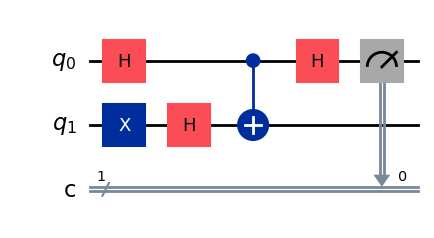

In [10]:
# Deutsch Algorithm Circuit

qc = QuantumCircuit(2,1)

qc.x(1)

qc.h(0)
qc.h(1)

if oracle_choice == "constant":

    oracle = oracle_constant_zero()

else:

    oracle = oracle_balanced_identity()

qc.compose(oracle,inplace=True)

qc.h(0)

qc.measure(0,0)

display(qc.draw("mpl"))

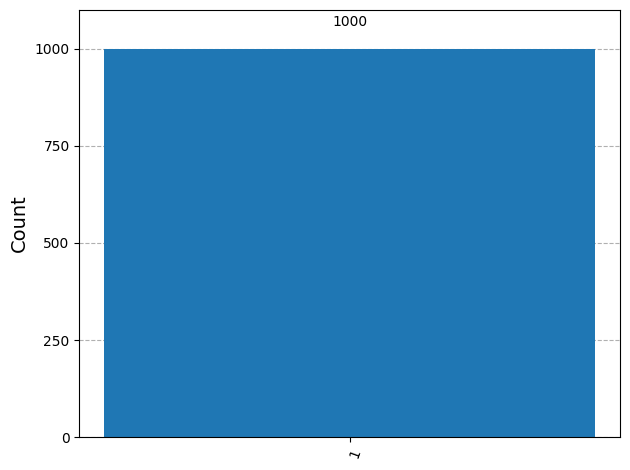


DEUTSCH ALGORITHM RESULT

Function is BALANCED


In [11]:
sim = AerSimulator()

result = sim.run(
    qc,
    shots=1000
).result()

counts = result.get_counts()

display(plot_histogram(counts))

measurement = max(counts,key=counts.get)

print()
print("="*60)
print("DEUTSCH ALGORITHM RESULT")
print("="*60)

if measurement == "0":

    print()
    print("Function is CONSTANT")

else:

    print()
    print("Function is BALANCED")

# Deutsch-Jozsa Algorithm

Generalization of Deutsch Algorithm.

Input:

n qubits

Promise:

Function is either:

- Constant
or
- Balanced

Goal:

Determine which one with ONE oracle call.

In [12]:
# Constant Oracle

def dj_constant(n):

    return QuantumCircuit(n+1)


# Balanced Oracle

def dj_balanced(n):

    qc = QuantumCircuit(n+1)

    for q in range(n):
        qc.cx(q,n)

    return qc

# Interactive Input Size

n = 3

oracle_type = "balanced"

print()
print("Number of Input Qubits:",n)
print("Oracle Type:",oracle_type)


Number of Input Qubits: 3
Oracle Type: balanced


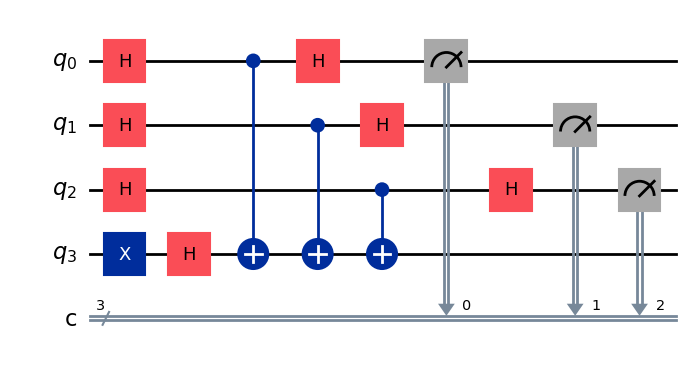

In [13]:
qc = QuantumCircuit(n+1,n)

qc.x(n)

for q in range(n+1):
    qc.h(q)

if oracle_type == "constant":

    oracle = dj_constant(n)

else:

    oracle = dj_balanced(n)

qc.compose(oracle,inplace=True)

for q in range(n):
    qc.h(q)

qc.measure(range(n),range(n))

display(qc.draw("mpl"))

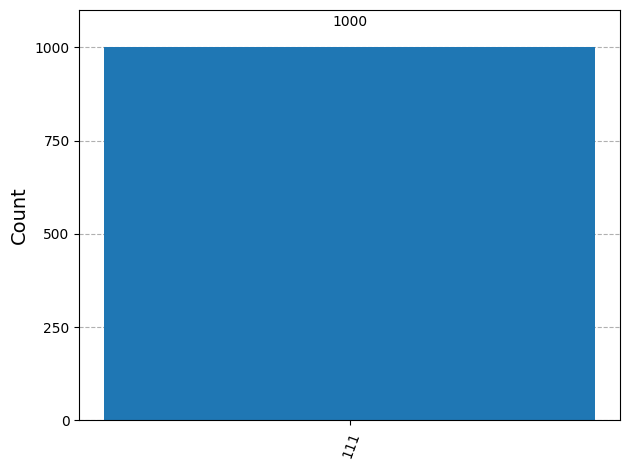


DEUTSCH-JOZSA RESULT

Measured State: 111

FUNCTION IS BALANCED


In [16]:
sim = AerSimulator()

result = sim.run(
    qc,
    shots=1000
).result()

counts = result.get_counts()

display(plot_histogram(counts))

measurement = max(counts,key=counts.get)

print()
print("="*60)
print("DEUTSCH-JOZSA RESULT")
print("="*60)

print()
print("Measured State:",measurement)

if measurement == "000":

    print()
    print("FUNCTION IS CONSTANT")

else:

    print()
    print("FUNCTION IS BALANCED")

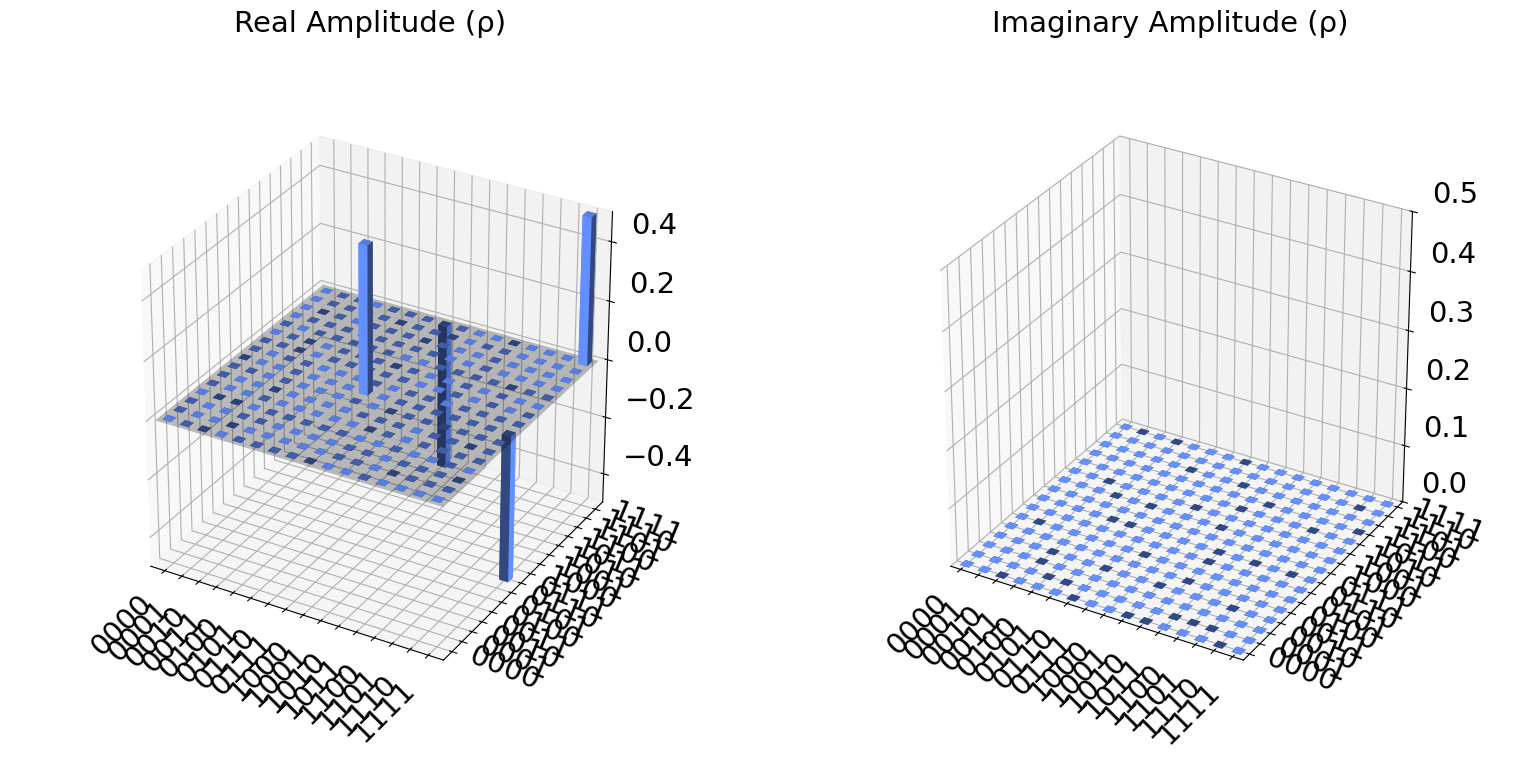

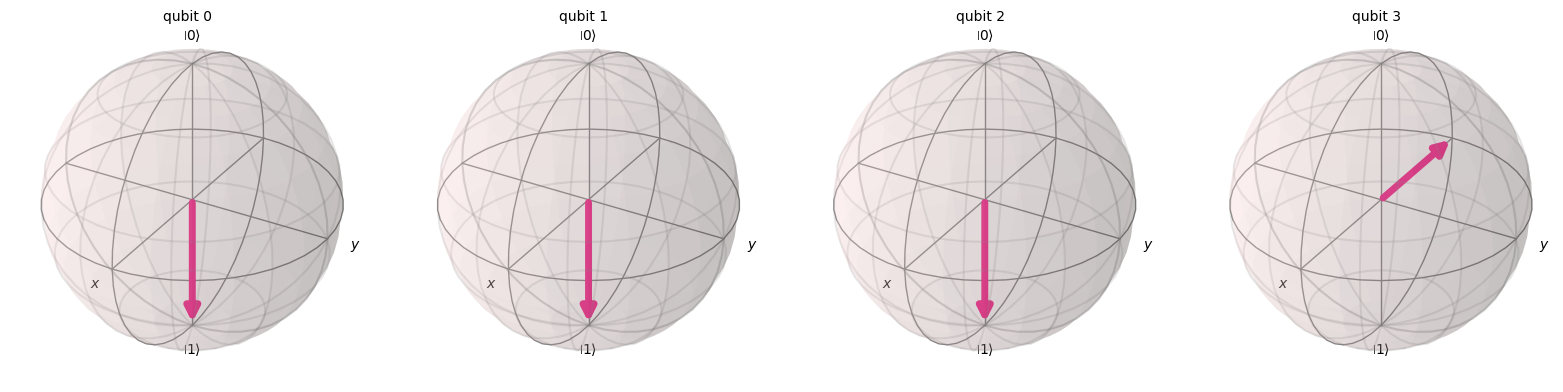

In [17]:
state = Statevector.from_instruction(
    qc.remove_final_measurements(inplace=False)
)

display(plot_state_city(state))
display(plot_bloch_multivector(state))